In [2]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training.train_state import TrainState

from flightning import FLIGHTNING_PATH
from flightning.algos import bptt
from flightning.envs import StabilisingCartPoleEnv, rollout
from flightning.envs.wrappers import MinMaxObservationWrapper
from flightning.modules import MLP

%matplotlib inline

# Training a State-based Quadrotor Policy With BPTT

## Seed it

In [3]:
seed = 42
key = jax.random.key(seed)
key_init, key_bptt = jax.random.split(key, 2)

## Setup the Training Environment

In [4]:
drone_path = FLIGHTNING_PATH + "/objects/quadrotor_files/example_quad.yaml"
dt = 0.02

env = StabilisingCartPoleEnv(
    max_steps_in_episode=3 * int(1 / dt),
    dt=dt,
    gravity=9.81,
    length=1.0,
    mass_cart=1.0,
    mass_pole=0.1,
    friction_cart=0.0,
    friction_pole=0.0,
    x_limit=2.4,
    theta_limit=jnp.pi / 2,
    force_limit=10.0,
    x_dot_std=0.1,
    theta_dot_std=0.1,
    q_x=1.0,
    q_theta=10.0,
    q_x_dot=0.1,
    q_theta_dot=0.1,
    r_force=0.01,
)
env = MinMaxObservationWrapper(env)

# get dims
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]

## Define the Policy Network

In [5]:
policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    initial_scale=0.01,
    action_bias=env.hovering_action,
)
policy_params = policy_net.initialize(key_init)

## Setup the Optimizer and Train State

In [6]:
N = 1000
scheduler = optax.cosine_decay_schedule(1e-2, N)
tx = optax.adam(scheduler)
train_state = TrainState.create(
    apply_fn=policy_net.apply, params=policy_params, tx=tx
)

## Initial Rollout

In [7]:
def get_rollouts(env, policy, num_rollouts, key):
    parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None))
    rollout_keys = jax.random.split(key, num_rollouts)
    transitions = parallel_rollout(env, rollout_keys, policy)
    return transitions


def policy(obs, key):
    return train_state.apply_fn(train_state.params, obs)

transitions = get_rollouts(env, policy, 10, jax.random.key(3))

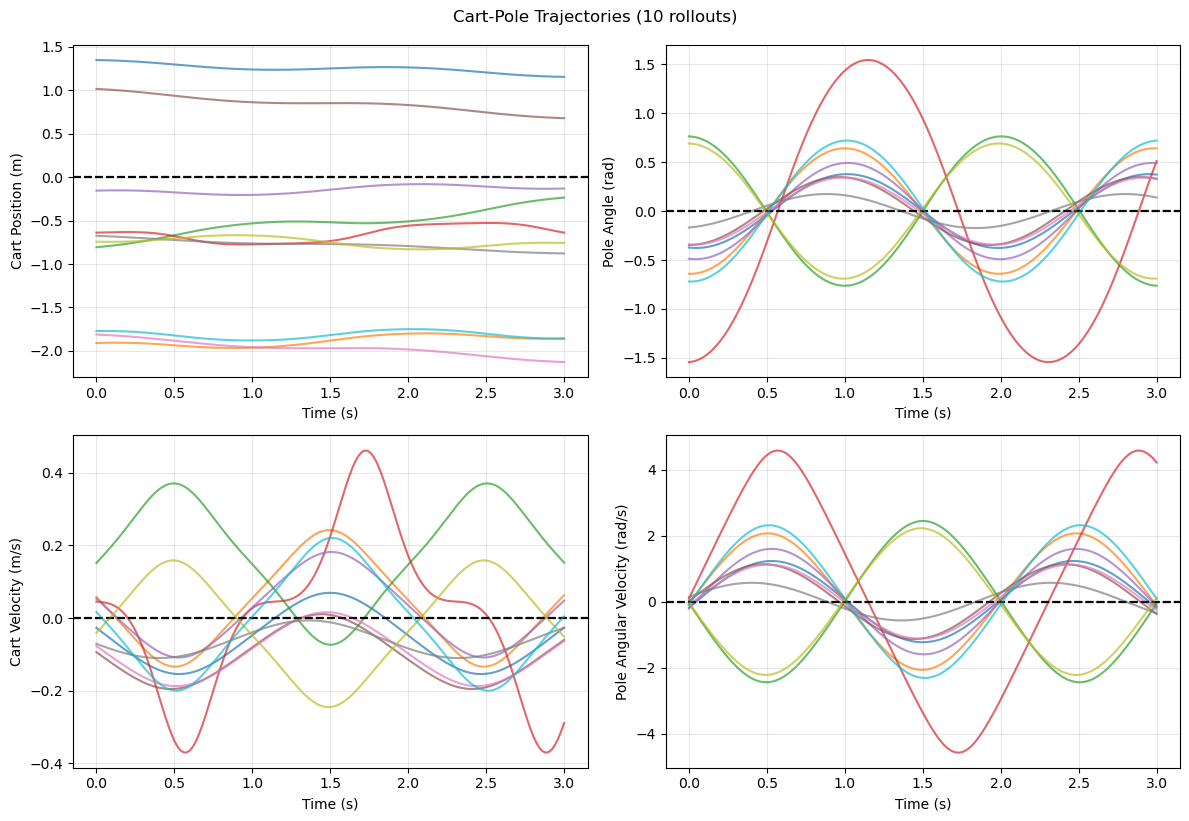

In [8]:
env.plot_trajectories(transitions)

## Train the Policy Using BPTT

In [9]:
time_start = time.time()
res_dict = bptt.train(
    env,
    train_state,
    num_epochs=100,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=100,
    key=key_bptt,
)
time_train = time.time() - time_start
print(f"Training time: {time_train}")

Episode: 0, Loss: 17.89
Episode: 0, Grad max: 1.0377
Episode: 10, Loss: 6.68
Episode: 10, Grad max: 1.1999
Episode: 20, Loss: 5.35
Episode: 20, Grad max: 0.0883
Episode: 30, Loss: 5.01
Episode: 30, Grad max: 0.0600
Episode: 40, Loss: 4.96
Episode: 40, Grad max: 0.0637
Episode: 50, Loss: 5.50
Episode: 50, Grad max: 0.0355
Episode: 60, Loss: 5.05
Episode: 60, Grad max: 0.0157
Episode: 70, Loss: 5.29
Episode: 70, Grad max: 0.0177
Episode: 80, Loss: 4.65
Episode: 80, Grad max: 0.0424
Episode: 90, Loss: 4.95
Episode: 90, Grad max: 0.0400
Training time: 14.986130952835083


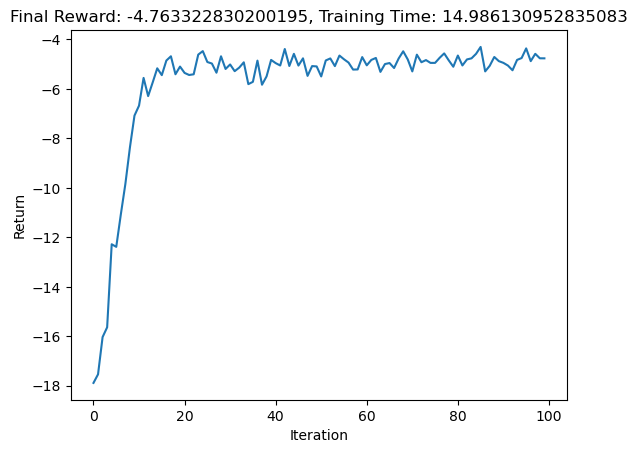

In [10]:
rewards = -res_dict["metrics"]
plt.plot(rewards)
plt.title(f"Final Reward: {rewards[-1]}, Training Time: {time_train}")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.show()

## Evaluate the Trained Policy

In [11]:
new_train_state = res_dict["runner_state"].train_state

def policy_trained(obs, key):
    return train_state.apply_fn(new_train_state.params, obs)

In [12]:
env_eval = StabilisingCartPoleEnv(
    max_steps_in_episode=8 * int(1 / dt),
    dt=dt,
    gravity=9.81,
    length=1.0,
    mass_cart=1.0,
    mass_pole=0.1,
    friction_cart=0.0,
    friction_pole=0.0,
    x_limit=2.4,
    theta_limit=jnp.pi / 2,
    force_limit=10.0,
    x_dot_std=0.1,
    theta_dot_std=0.1,
    q_x=1.0,
    q_theta=10.0,
    q_x_dot=0.1,
    q_theta_dot=0.1,
    r_force=0.01,
)
env_eval = MinMaxObservationWrapper(env_eval)

transitions_eval = get_rollouts(env_eval, policy_trained, 20, jax.random.key(3))

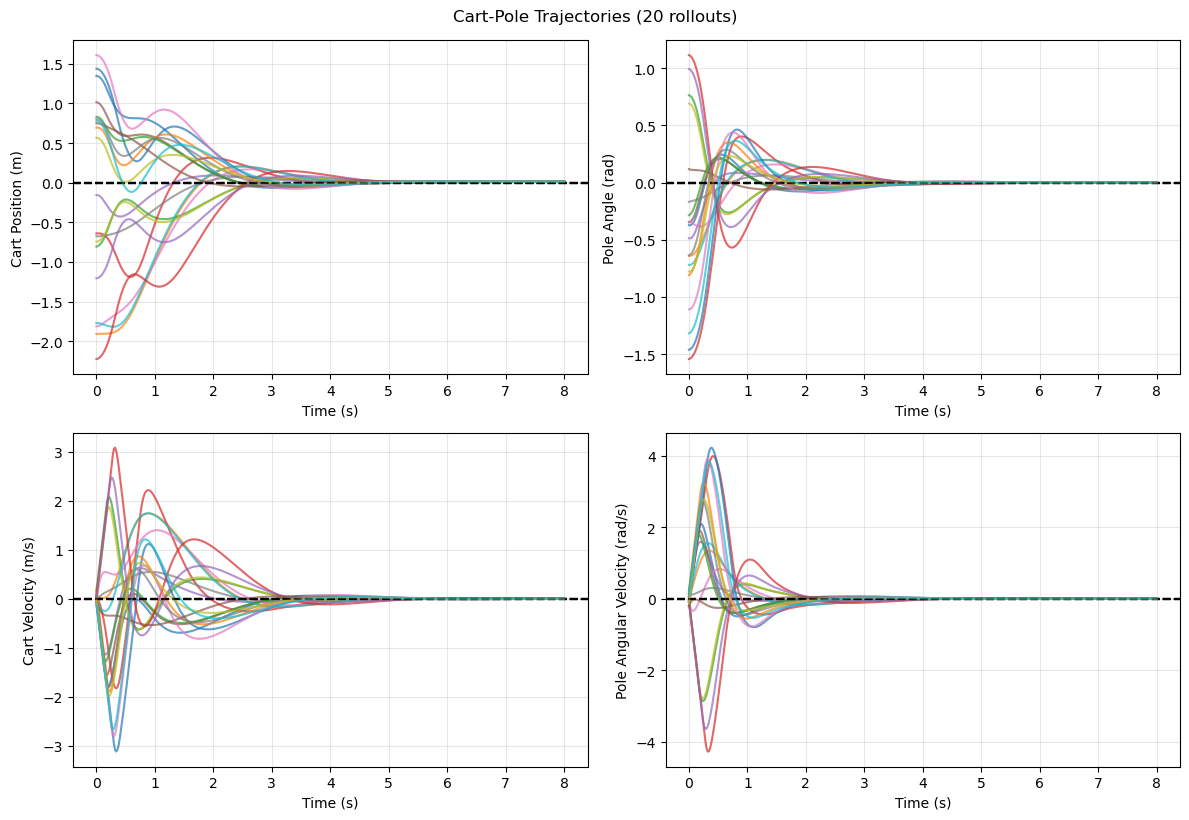

In [13]:
env_eval.plot_trajectories(transitions_eval)